In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere,plot_state_city,plot_histogram
from qiskit.circuit.library import QFTGate

ModuleNotFoundError: No module named 'qiskit_aer'

In [8]:
import matplotlib.pyplot as plt

'q_initial:'

<IPython.core.display.Latex object>

'q_final:'

<IPython.core.display.Latex object>

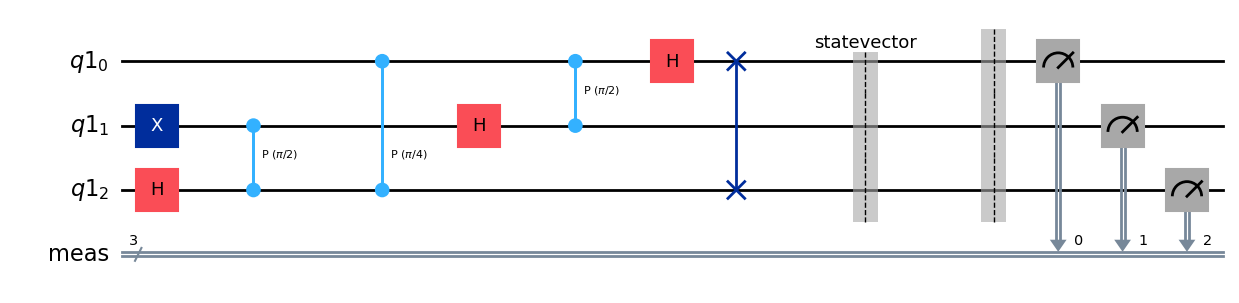

Measurement Counts: {'101': 128, '110': 116, '011': 124, '111': 126, '010': 141, '000': 125, '001': 131, '100': 133}


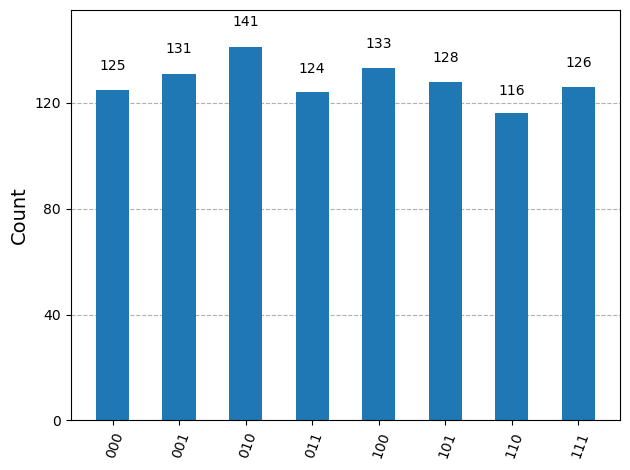

In [9]:
q = QuantumRegister(3)
qc = QuantumCircuit(q)

#State preparation (010)
qc.x(q[1])

#Simulator
simulator = AerSimulator()

#Displaying initial statevector
qc_init = qc.copy()
qc_init.save_statevector()
statevector = simulator.run(qc_init).result().get_statevector()
display("q_initial:",statevector.draw("latex"))


#step 1: Hadamard gate
qc.h(q[2])
qc.cp(np.pi/2,q[1],q[2])
qc.cp(np.pi/4,q[0],q[2])
#repeat same steps for other qubits
#step1: hadamard gate
qc.h(q[1])
#step 2: apply controlled rotation
qc.cp(np.pi/2,q[0],q[1])
#hadamard gate
qc.h(q[0])
#swap qubits before measurement
qc.swap(q[0],q[2])

#displaying final statevector
qc_fin = qc.copy()
qc_fin.save_statevector()
statevector = simulator.run(qc_fin).result().get_statevector()
display("q_final:",statevector.draw("latex"))

#Measurement
qc_fin.measure_all()

#Display the circuit
display(qc_fin.draw("mpl"))

# execute circuit with AerSimulator
job = simulator.run([qc_fin])
result = job.result()
counts = result.get_counts(0)
print(f"Measurement Counts: {counts}")
plot_histogram(counts)

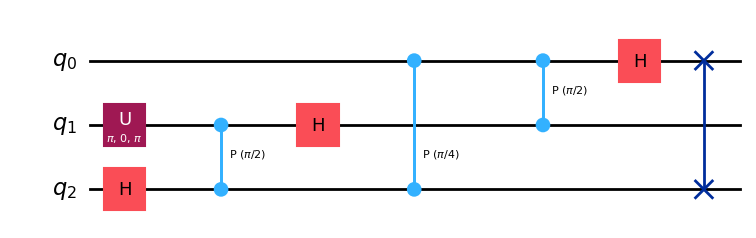

In [10]:
qc = QuantumCircuit(3)
qc.x(1)
qc.compose(QFTGate(3), inplace=True)
qc.decompose().draw("mpl")